# 01 - Data Extraction and Exploratory Data Analysis

**Project:** Industrial Surface Defect Detection (CO543 Computer Vision, Group G08, Project P17)

Before writing the full pipeline scripts we experimented with every stage of the project in notebooks. This first notebook covers how we obtained the MVTec Anomaly Detection dataset and what we learned from exploring it.

**Dataset:** MVTec AD (Bergmann et al., 2021), a real world industrial inspection benchmark. Each category provides:

- `train/good/` with only defect free images (this is what makes the task unsupervised)
- `test/<defect_type>/` with both normal and defective test images
- `ground_truth/<defect_type>/` with pixel level binary masks marking the exact defect regions

We use three categories chosen to cover different surface types: **bottle** (rigid object), **hazelnut** (organic object) and **carpet** (texture). Object defects and texture defects behave very differently for anomaly detection, so this selection stresses both scenarios.

**License:** CC BY-NC-SA 4.0, non commercial use only.

In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = Path('../data/mvtec_ad')
CATEGORIES = ['bottle', 'hazelnut', 'carpet']

np.random.seed(42)
print('Data root:', DATA_ROOT)
print('Categories:', CATEGORIES)

Data root: ..\data\mvtec_ad
Categories: ['bottle', 'hazelnut', 'carpet']


## 1. Data Acquisition

MVTec provides each category as a separate `.tar.xz` archive on their mydrive mirror. Our extraction logic downloads the archive for a category, unpacks it into `data/mvtec_ad/` and verifies that the expected directory structure appeared. If a category is already present it is skipped, so the cell is safe to re run.

This same logic later became `scripts/download_data.py`, with an anomalib based auto download as a fallback method.

In [2]:
import tarfile
import urllib.request

MVTEC_URLS = {
    'bottle': 'https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420937370-1629951468/bottle.tar.xz',
    'hazelnut': 'https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420937484-1629951845/hazelnut.tar.xz',
    'carpet': 'https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420937078-1629951672/carpet.tar.xz',
}


def check_category_exists(category):
    """A category counts as downloaded when train/good and test both exist and are non empty."""
    cat_dir = DATA_ROOT / category
    required = [cat_dir / 'train' / 'good', cat_dir / 'test']
    return all(d.exists() and any(d.iterdir()) for d in required)


def download_and_extract(category):
    """Download the category tarball and extract it into DATA_ROOT."""
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    tar_path = DATA_ROOT / f'{category}.tar.xz'
    print(f'  Downloading {category}.tar.xz ...')
    urllib.request.urlretrieve(MVTEC_URLS[category], tar_path)
    print('  Extracting ...')
    with tarfile.open(tar_path, 'r:xz') as tar:
        tar.extractall(path=str(DATA_ROOT))
    tar_path.unlink()
    return check_category_exists(category)


for category in CATEGORIES:
    if check_category_exists(category):
        print(f'[{category}] already extracted, skipping download')
    else:
        ok = download_and_extract(category)
        print(f'[{category}]', 'downloaded and extracted' if ok else 'FAILED')

[bottle] already extracted, skipping download
[hazelnut] already extracted, skipping download
[carpet] already extracted, skipping download


## 2. Directory Structure

A quick walk over the extracted folders confirms the three way split (train, test, ground_truth) and shows which defect types each category contains.

In [3]:
for cat in CATEGORIES:
    cat_dir = DATA_ROOT / cat
    print(f'{cat}/')
    for section in ['train', 'test', 'ground_truth']:
        sec_dir = cat_dir / section
        if not sec_dir.exists():
            continue
        print(f'  {section}/')
        for sub in sorted(sec_dir.iterdir()):
            if sub.is_dir():
                n = len(list(sub.glob('*.png')))
                print(f'    {sub.name}/  ({n} images)')
    print()

bottle/
  train/
    good/  (209 images)
  test/
    broken_large/  (20 images)
    broken_small/  (22 images)
    contamination/  (21 images)
    good/  (20 images)
  ground_truth/
    broken_large/  (20 images)
    broken_small/  (22 images)
    contamination/  (21 images)

hazelnut/
  train/
    good/  (391 images)
  test/
    crack/  (18 images)
    cut/  (17 images)
    good/  (40 images)
    hole/  (18 images)
    print/  (17 images)
  ground_truth/
    crack/  (18 images)
    cut/  (17 images)
    hole/  (18 images)
    print/  (17 images)

carpet/
  train/
    good/  (280 images)
  test/
    color/  (19 images)
    cut/  (17 images)
    good/  (28 images)
    hole/  (17 images)
    metal_contamination/  (17 images)
    thread/  (19 images)
  ground_truth/
    color/  (19 images)
    cut/  (17 images)
    hole/  (17 images)
    metal_contamination/  (17 images)
    thread/  (19 images)



## 3. Dataset Statistics

We tabulate image counts per category. Two things matter for the modeling stages later:

- the training sets are small (a few hundred images) and contain **only** normal samples
- every test set mixes normal images with several defect types, so image level labels for evaluation come from the folder names

In [4]:
rows = []
for cat in CATEGORIES:
    cat_dir = DATA_ROOT / cat
    train_count = len(list((cat_dir / 'train' / 'good').glob('*.png')))
    test_good = len(list((cat_dir / 'test' / 'good').glob('*.png')))
    test_defective = 0
    defect_types = []
    for sub in sorted((cat_dir / 'test').iterdir()):
        if sub.is_dir() and sub.name != 'good':
            n = len(list(sub.glob('*.png')))
            test_defective += n
            defect_types.append(f'{sub.name} ({n})')
    rows.append({
        'category': cat,
        'train good': train_count,
        'test good': test_good,
        'test defective': test_defective,
        'defect types': ', '.join(defect_types),
    })

stats = pd.DataFrame(rows)
stats

,category,train good,test good,test defective,defect types
0,bottle,209,20,63,"broken_large (20), broken_small (22), contamin..."
1,hazelnut,391,40,70,"crack (18), cut (17), hole (18), print (17)"
2,carpet,280,28,89,"color (19), cut (17), hole (17), metal_contami..."


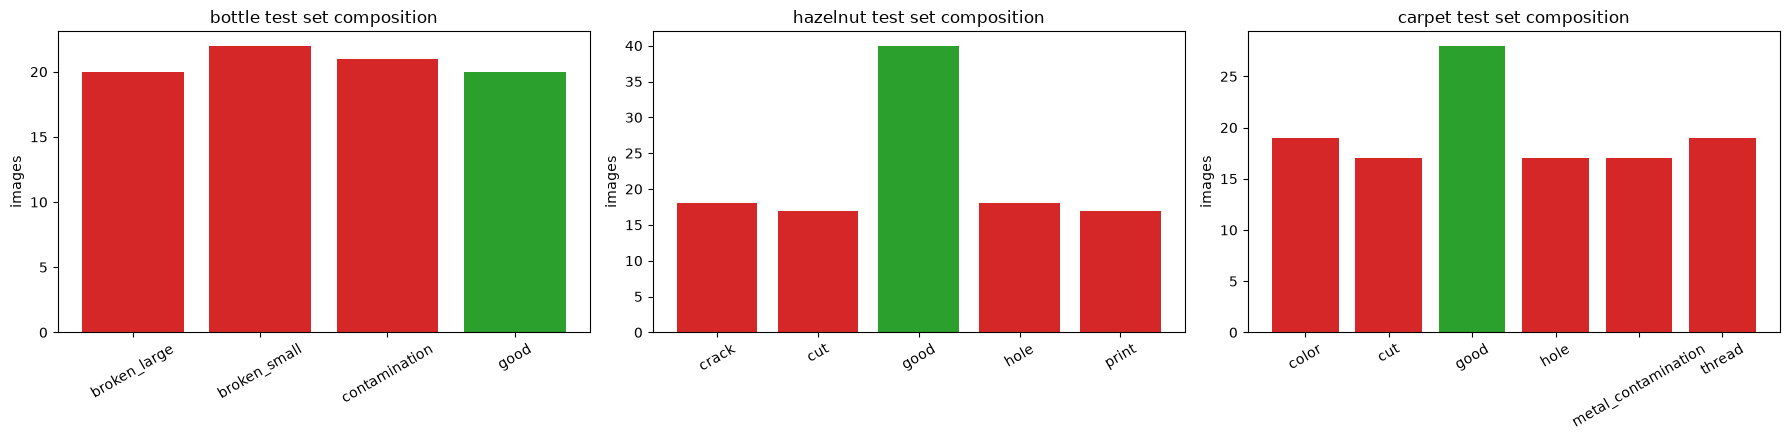

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, cat in zip(axes, CATEGORIES):
    counts = {}
    for sub in sorted((DATA_ROOT / cat / 'test').iterdir()):
        if sub.is_dir():
            counts[sub.name] = len(list(sub.glob('*.png')))
    colors = ['tab:green' if k == 'good' else 'tab:red' for k in counts]
    ax.bar(list(counts.keys()), list(counts.values()), color=colors)
    ax.set_title(f'{cat} test set composition')
    ax.set_ylabel('images')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Sample Images: Good vs Defective

Side by side samples per category. Note how subtle some defects are, especially on carpet where the normal texture already looks irregular. This observation ends up explaining our baseline results later.

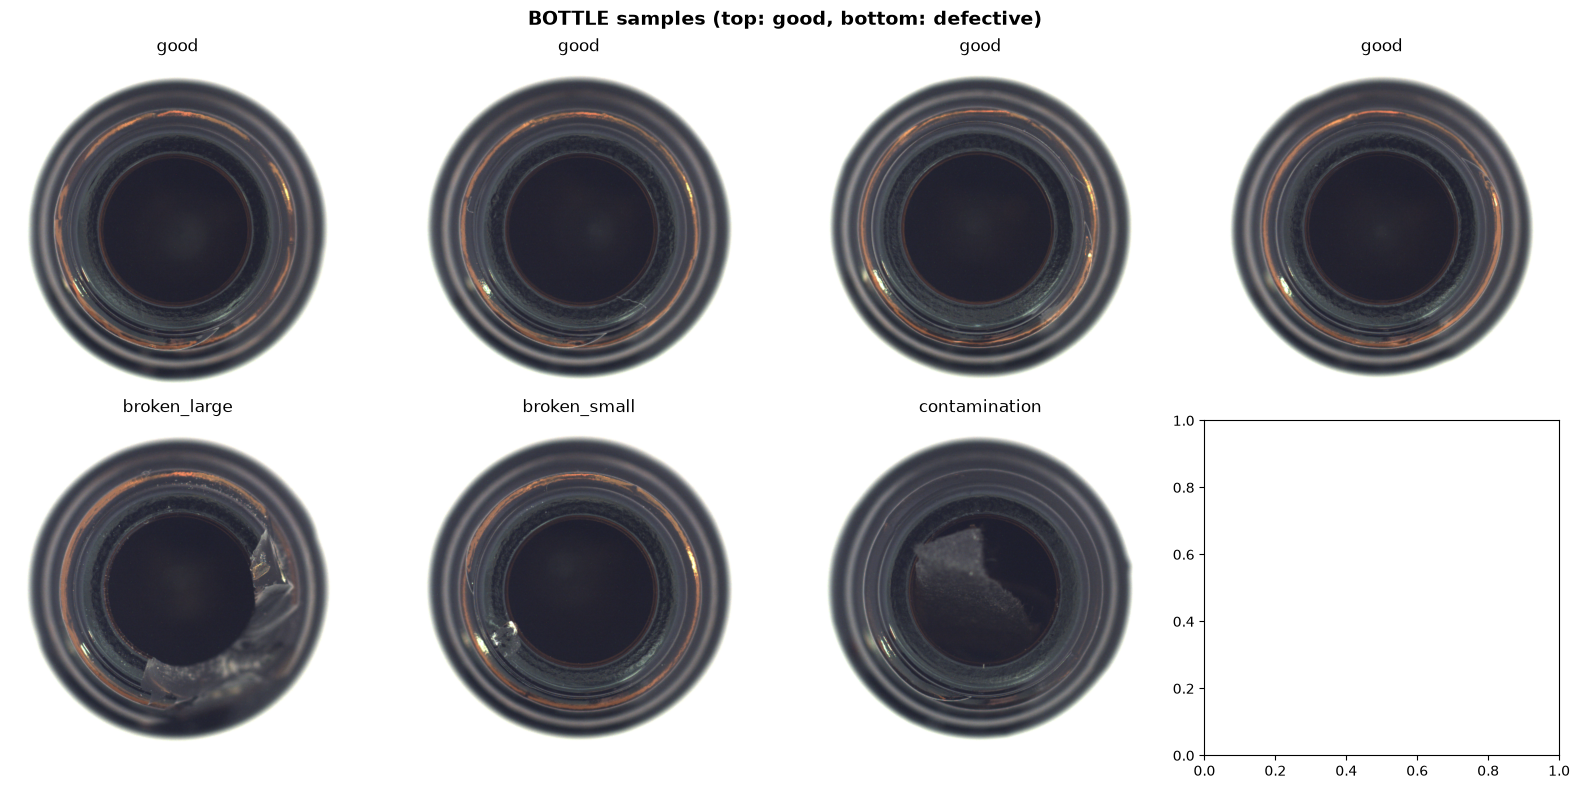

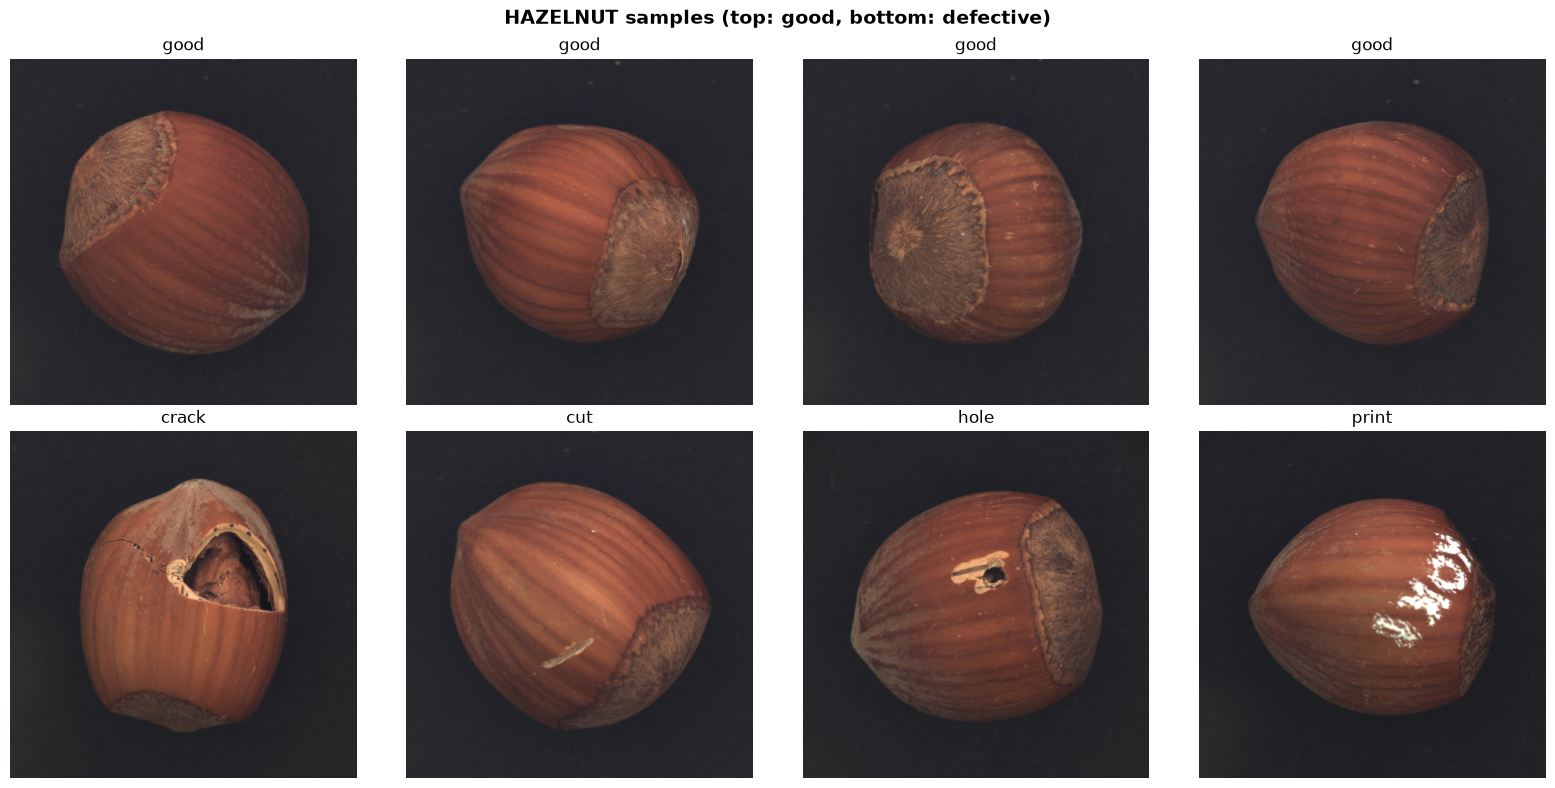

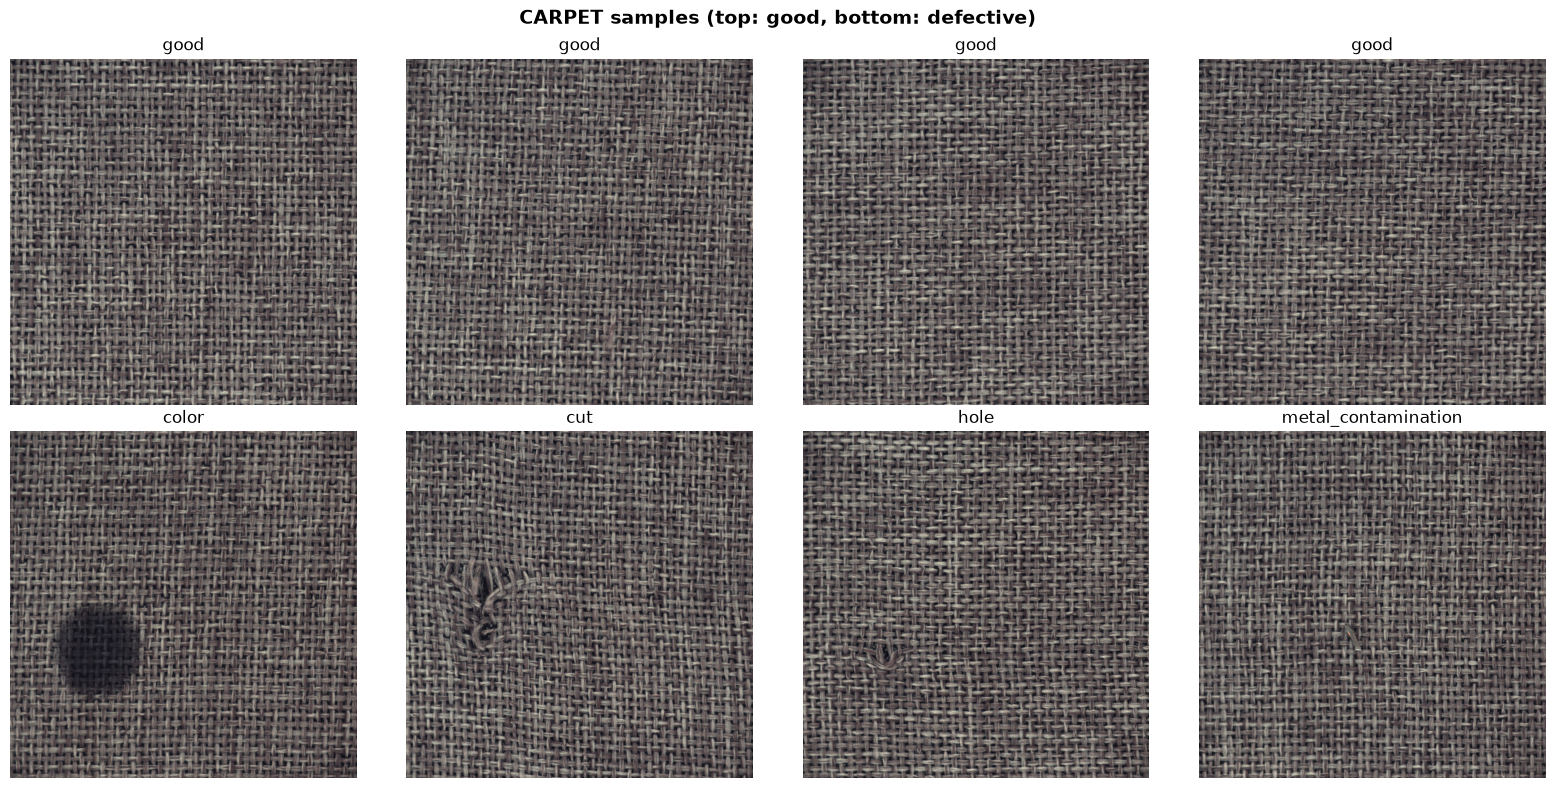

In [6]:
for cat in CATEGORIES:
    cat_dir = DATA_ROOT / cat
    good_paths = sorted((cat_dir / 'test' / 'good').glob('*.png'))[:4]
    defect_dirs = [d for d in sorted((cat_dir / 'test').iterdir()) if d.is_dir() and d.name != 'good']
    defect_paths = []
    for d in defect_dirs:
        defect_paths.extend(sorted(d.glob('*.png'))[:1])
    defect_paths = defect_paths[:4]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{cat.upper()} samples (top: good, bottom: defective)', fontsize=14, fontweight='bold')
    for i, p in enumerate(good_paths):
        axes[0, i].imshow(Image.open(p))
        axes[0, i].set_title('good')
        axes[0, i].axis('off')
    for i, p in enumerate(defect_paths):
        axes[1, i].imshow(Image.open(p))
        axes[1, i].set_title(p.parent.name)
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

## 5. Ground Truth Mask Visualization

Each defective test image has a binary mask in `ground_truth/` where white pixels mark the defect. We overlay the mask in red on the original image using alpha blending (0.6 times the original plus 0.4 times a red tinted copy). These masks are what pixel level localization metrics are scored against later.

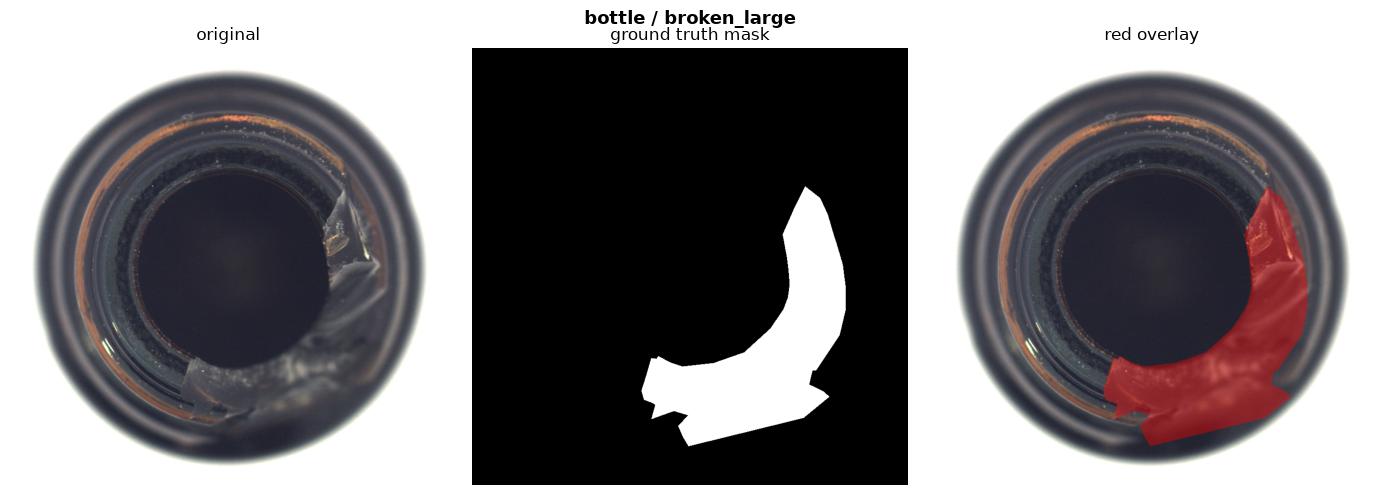

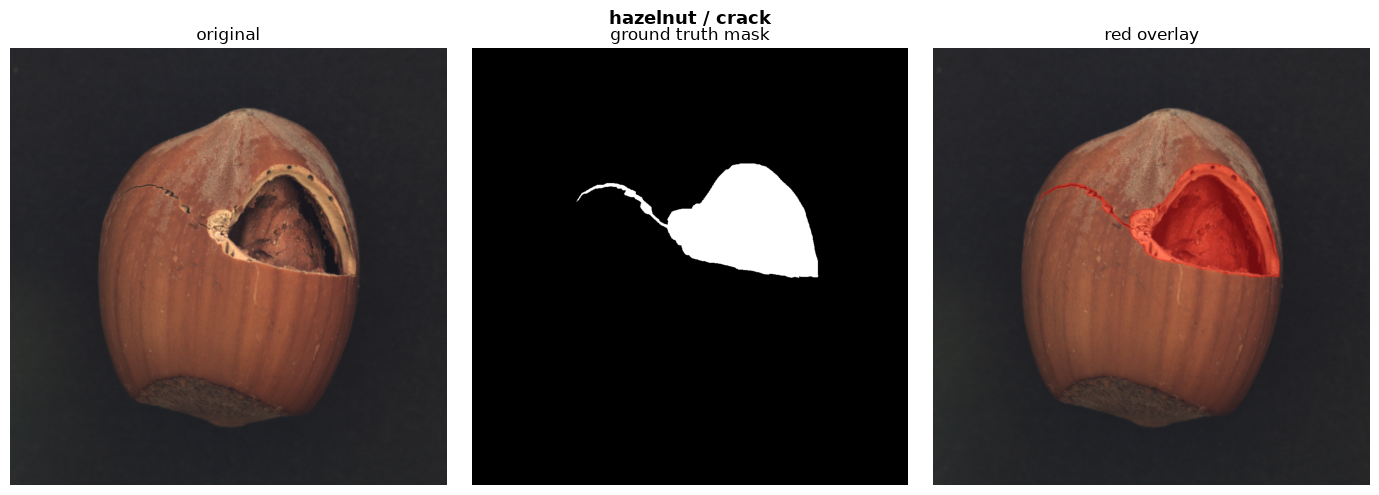

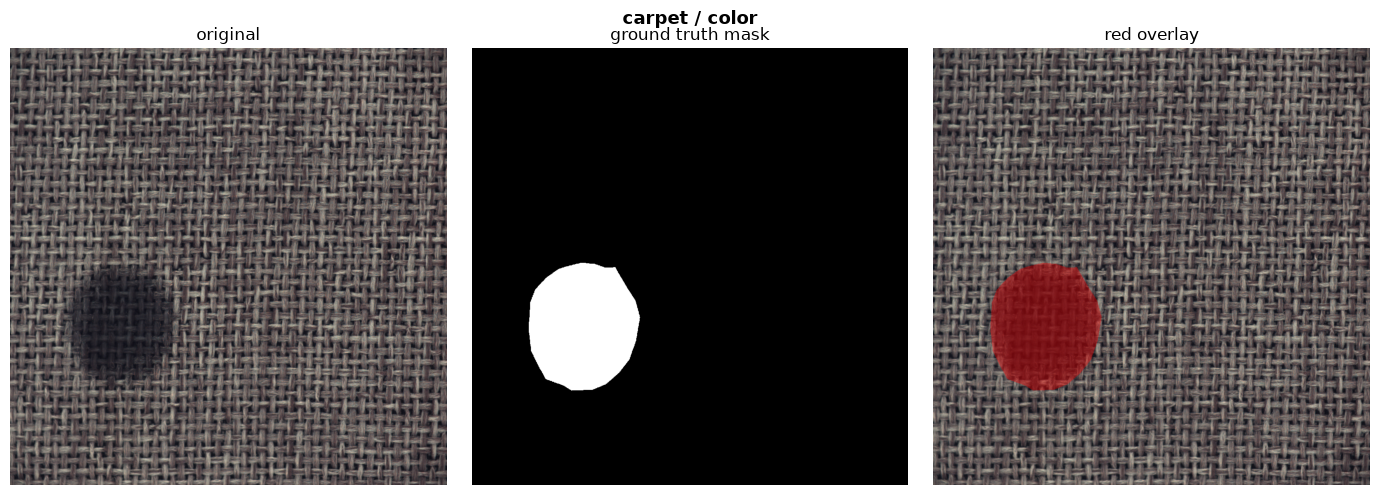

In [7]:
def red_overlay(image, mask, alpha=0.4):
    """Blend a red tint into the image wherever mask > 0."""
    img = np.asarray(image, dtype=np.float32) / 255.0
    m = np.asarray(mask, dtype=np.float32) / 255.0
    overlay = img.copy()
    red = np.zeros_like(img)
    red[..., 0] = 1.0
    blend = (1 - alpha) * img + alpha * red
    overlay[m > 0.5] = blend[m > 0.5]
    return overlay


for cat in CATEGORIES:
    cat_dir = DATA_ROOT / cat
    defect_dirs = [d for d in sorted((cat_dir / 'test').iterdir()) if d.is_dir() and d.name != 'good']
    d = defect_dirs[0]
    img_path = sorted(d.glob('*.png'))[0]
    mask_path = cat_dir / 'ground_truth' / d.name / (img_path.stem + '_mask.png')

    image = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f'{cat} / {d.name}', fontsize=13, fontweight='bold')
    axes[0].imshow(image); axes[0].set_title('original'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('ground truth mask'); axes[1].axis('off')
    axes[2].imshow(red_overlay(image, mask)); axes[2].set_title('red overlay'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

## 6. Image Properties

We check original resolutions and channel statistics on a sample of training images. This tells us what preprocessing is required before any model sees the data.

In [8]:
rows = []
for cat in CATEGORIES:
    train_dir = DATA_ROOT / cat / 'train' / 'good'
    sample_paths = sorted(train_dir.glob('*.png'))[:20]
    sizes = set()
    means, stds = [], []
    for p in sample_paths:
        img = np.asarray(Image.open(p).convert('RGB'), dtype=np.float32) / 255.0
        sizes.add(img.shape[:2])
        means.append(img.mean(axis=(0, 1)))
        stds.append(img.std(axis=(0, 1)))
    rows.append({
        'category': cat,
        'original sizes': ', '.join(f'{h}x{w}' for h, w in sorted(sizes)),
        'mean RGB': np.round(np.mean(means, axis=0), 3),
        'std RGB': np.round(np.mean(stds, axis=0), 3),
    })
pd.DataFrame(rows)

,category,original sizes,mean RGB,std RGB
0,bottle,900x900,"[0.534, 0.531, 0.547]","[0.367, 0.367, 0.35]"
1,hazelnut,1024x1024,"[0.239, 0.178, 0.175]","[0.156, 0.068, 0.037]"
2,carpet,1024x1024,"[0.364, 0.349, 0.353]","[0.146, 0.139, 0.127]"


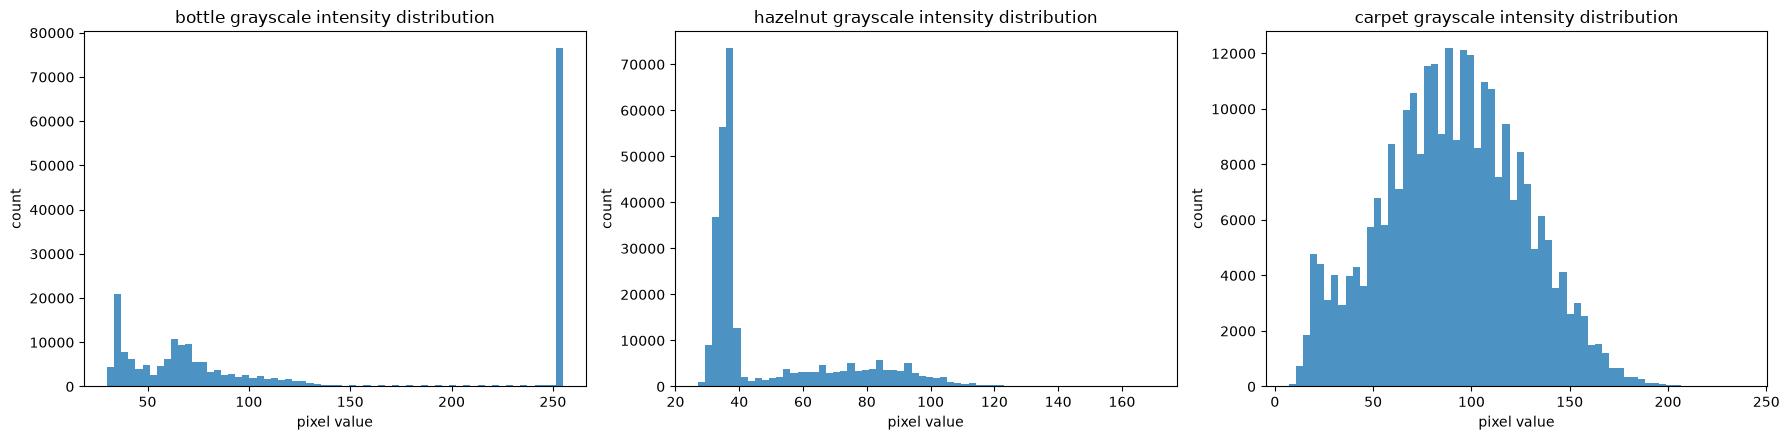

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, cat in zip(axes, CATEGORIES):
    train_dir = DATA_ROOT / cat / 'train' / 'good'
    sample_paths = sorted(train_dir.glob('*.png'))[:10]
    pixels = np.concatenate([
        np.asarray(Image.open(p).convert('L'), dtype=np.uint8).ravel()[::37]
        for p in sample_paths
    ])
    ax.hist(pixels, bins=64, color='tab:blue', alpha=0.8)
    ax.set_title(f'{cat} grayscale intensity distribution')
    ax.set_xlabel('pixel value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 7. Observations

- Original resolutions differ between categories (for example 900x900 for bottle and 1024x1024 for hazelnut and carpet), so **resizing to a common resolution is mandatory**. We settle on 256x256, the standard MVTec AD benchmark size.
- Training folders contain only good images. Any model we build must learn normality from these and flag deviations at test time. This rules out ordinary supervised classification.
- Defects usually occupy a small fraction of the image, so pixel level localization needs the ground truth masks and metrics that respect small regions.
- Carpet looks irregular even when normal. We flag this early as a likely hard case for reconstruction based methods.

The next notebook works out the preprocessing pipeline that all later experiments share.